# Fundamentals of Data Science
## Assessment Tool 3
### Question 3 – Retail Sales Dataset

### Objective

To perform Exploratory Data Analysis (EDA) on a retail sales dataset to identify product sales trends, revenue patterns, discounts, and category-wise performance for better business decision-making.

In [6]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## Dataset Description

### Problem Statement

A supermarket wants to analyze product sales based on category, price, quantity sold, discount, and revenue to identify high-selling products and revenue patterns.

### Dataset Features

- Product_ID
- Category
- Price
- Quantity_Sold
- Discount
- Revenue

### Target Variable

Revenue is considered the target variable because it reflects the overall sales performance.

In [8]:
# ==========================================================
# Create Retail Sales Dataset
# ==========================================================

retail = {
    "Product_ID":["PR01","PR02","PR03","PR04","PR05","PR06","PR07","PR08","PR09","PR10",
                  "PR11","PR12","PR13","PR14","PR15","PR16","PR17","PR18","PR19","PR20"],

    "Category":["Grocery","Snacks","Dairy","Fruits","Vegetables","Grocery","Snacks","Dairy",
                "Fruits","Vegetables","Grocery","Snacks","Dairy","Fruits","Vegetables",
                "Grocery","Snacks","Dairy","Fruits","Vegetables"],

    "Price":[50,30,45,60,40,80,25,55,70,35,90,20,65,75,45,100,35,50,80,30],

    "Quantity_Sold":[20,35,18,25,30,15,40,16,22,28,12,45,14,20,26,10,32,19,18,35],

    "Discount":[5,3,2,5,4,6,3,2,5,4,6,2,3,5,4,7,3,2,6,3],

    "Revenue":[1000,1050,810,1500,1200,1200,1000,880,1540,980,1080,900,910,1500,1170,1000,1120,950,1440,1050]
}

df3 = pd.DataFrame(retail)

df3.head()

,Product_ID,Category,Price,Quantity_Sold,Discount,Revenue
0,PR01,Grocery,50,20,5,1000
1,PR02,Snacks,30,35,3,1050
2,PR03,Dairy,45,18,2,810
3,PR04,Fruits,60,25,5,1500
4,PR05,Vegetables,40,30,4,1200


In [9]:
# ==========================================================
# Dataset Understanding
# ==========================================================

print("Shape of Dataset:")
print(df3.shape)

print("\nDataset Information:")
df3.info()

print("\nData Types:")
print(df3.dtypes)

Shape of Dataset:
(20, 6)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Product_ID     20 non-null     str  
 1   Category       20 non-null     str  
 2   Price          20 non-null     int64
 3   Quantity_Sold  20 non-null     int64
 4   Discount       20 non-null     int64
 5   Revenue        20 non-null     int64
dtypes: int64(4), str(2)
memory usage: 1.1 KB

Data Types:
Product_ID         str
Category           str
Price            int64
Quantity_Sold    int64
Discount         int64
Revenue          int64
dtype: object


In [10]:
# ==========================================================
# Data Cleaning
# ==========================================================

print("Missing Values")
print(df3.isnull().sum())

print("\nDuplicate Records")
print(df3.duplicated().sum())

print("\nAvailable Categories")
print(df3["Category"].unique())

Missing Values
Product_ID       0
Category         0
Price            0
Quantity_Sold    0
Discount         0
Revenue          0
dtype: int64

Duplicate Records
0

Available Categories
<StringArray>
['Grocery', 'Snacks', 'Dairy', 'Fruits', 'Vegetables']
Length: 5, dtype: str


In [11]:
# ==========================================================
# Descriptive Statistics
# ==========================================================

df3.describe()

,Price,Quantity_Sold,Discount,Revenue
count,20.000000,20.000000,20.000000,20.000000
mean,54.000000,24.000000,4.000000,1114.000000
std,22.803509,9.673621,1.555973,221.416493
min,20.000000,10.000000,2.000000,810.000000
25%,35.000000,17.500000,3.000000,972.500000
50%,50.000000,21.000000,4.000000,1050.000000
75%,71.250000,30.500000,5.000000,1200.000000
max,100.000000,45.000000,7.000000,1540.000000


In [12]:
# ==========================================================
# Numerical & Categorical Analysis
# ==========================================================

print("Average Price:", df3["Price"].mean())
print("Average Quantity Sold:", df3["Quantity_Sold"].mean())
print("Average Revenue:", df3["Revenue"].mean())

print("\nCategory-wise Product Count")
print(df3["Category"].value_counts())

Average Price: 54.0
Average Quantity Sold: 24.0
Average Revenue: 1114.0

Category-wise Product Count
Category
Grocery       4
Snacks        4
Dairy         4
Fruits        4
Vegetables    4
Name: count, dtype: int64


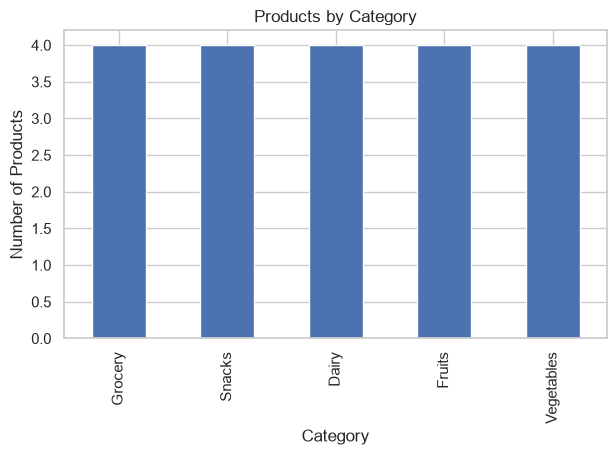

In [13]:
# ==========================================================
# Bar Chart - Category Distribution
# ==========================================================

plt.figure(figsize=(7,4))

df3["Category"].value_counts().plot(kind="bar")

plt.title("Products by Category")
plt.xlabel("Category")
plt.ylabel("Number of Products")

plt.show()

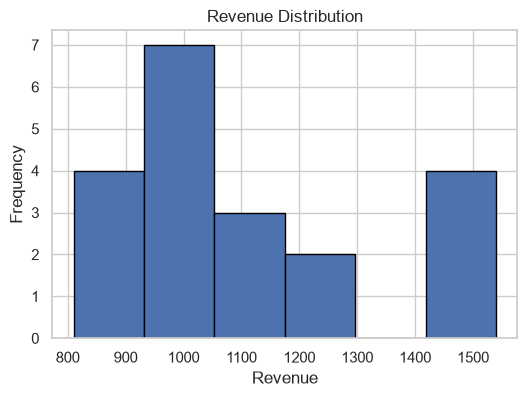

In [14]:
# ==========================================================
# Histogram - Revenue Distribution
# ==========================================================

plt.figure(figsize=(6,4))

plt.hist(df3["Revenue"], bins=6, edgecolor="black")

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()

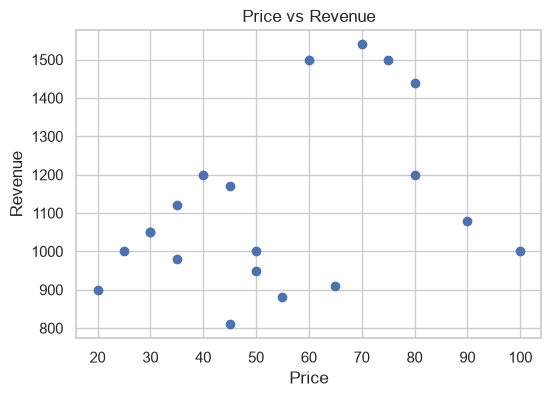

In [15]:
# ==========================================================
# Scatter Plot
# ==========================================================

plt.figure(figsize=(6,4))

plt.scatter(df3["Price"], df3["Revenue"])

plt.title("Price vs Revenue")
plt.xlabel("Price")
plt.ylabel("Revenue")

plt.show()

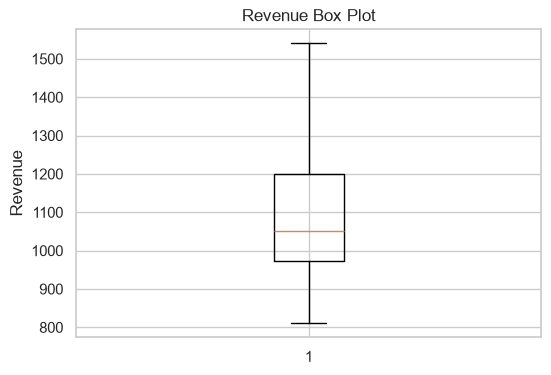

In [16]:
# ==========================================================
# Box Plot
# ==========================================================

plt.figure(figsize=(6,4))

plt.boxplot(df3["Revenue"])

plt.title("Revenue Box Plot")

plt.ylabel("Revenue")

plt.show()

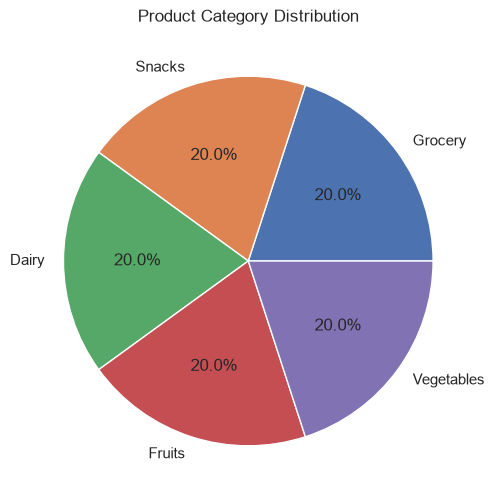

In [17]:
# ==========================================================
# Pie Chart
# ==========================================================

plt.figure(figsize=(6,6))

df3["Category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Product Category Distribution")
plt.ylabel("")

plt.show()

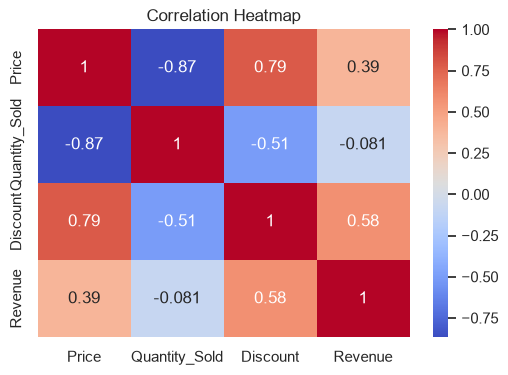

In [18]:
# ==========================================================
# Heatmap
# ==========================================================

plt.figure(figsize=(6,4))

sns.heatmap(
    df3.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## Observations

1. Fruits and Grocery products generated some of the highest revenues.
2. Higher-priced products do not always generate the highest revenue because quantity sold also affects revenue.
3. Discounts vary across product categories and may influence sales.
4. No missing values or duplicate records were found.
5. Revenue is positively related to both price and quantity sold.

## Conclusion

The EDA shows that product price, quantity sold, and discounts influence revenue generation. Category-wise analysis helps identify better-performing product groups. These insights can support inventory planning, pricing strategies, and sales improvement decisions.